<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>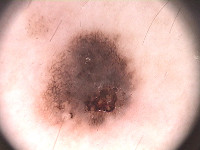</td><td>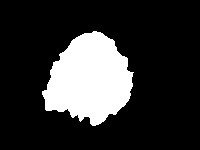</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [1]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=ba8864c3-c1f0-4730-81d7-27beee32ab40
To: /kaggle/working/PH2Dataset.rar
100%|████████████████████████████████████████| 162M/162M [00:01<00:00, 88.3MB/s]


In [2]:
get_ipython().system_raw("unrar x PH2Dataset.rar")


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from PH2Dataset.rar

Creating    PH2Dataset                                                OK
Creating    PH2Dataset/PH2 Dataset images                             OK
Creating    PH2Dataset/PH2 Dataset images/IMD002                      OK
Creating    PH2Dataset/PH2 Dataset images/IMD002/IMD002_Dermoscopic_Image  OK
Extracting  PH2Dataset/PH2 Dataset images/IMD002/IMD002_Dermoscopic_Image/IMD002.bmp     0  OK 
Creating    PH2Dataset/PH2 Dataset images/IMD002/IMD002_lesion        OK
Extracting  PH2Dataset/PH2 Dataset images/IMD002/IMD002_lesion/IMD002_lesion.bmp     0  OK 
Creating    PH2Dataset/PH2 Dataset images/IMD002/IMD002_roi           OK
Extracting  PH2Dataset/PH2 Dataset images/IMD002/IMD002_roi/IMD002_R1_Label4.bmp     0  OK 
Extracting  PH2Dataset/PH2 Dataset images/IMD002/IMD002_roi/IMD002_R2_Label3.bmp     0  OK 
Creating    PH2Dataset/PH2 Dataset images/IMD003                      OK
Crea

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [3]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

In [4]:
len(images)

200

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [5]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [6]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

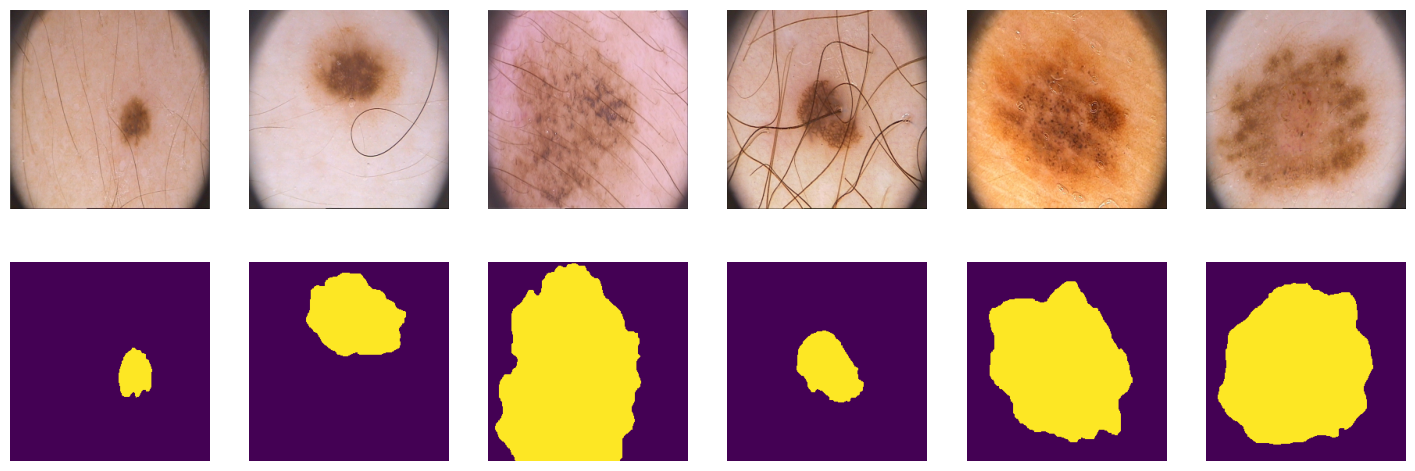

In [7]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [8]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [9]:
print(len(tr), len(val), len(ts))

100 50 50


In [10]:
print(tr)

[131 170  33 133  22  20 196  51  88  50  61 120 142 158  54 160 123  13
  72  48  99  95 132 152 175 127  52 167  64 166 145 114  23  93 118  74
 185 138  66 116 125  58  68   2  86  92 155  89 188  26 186 128 177  30
  73 184  39 183   6 139 102 198 117 105  44  41  81 187 173 143  63  40
 194  76 100  60  87  82  75  46  79 126   8  97  27 165 135 115 169  67
  38  17  10 159  16 191  31 193 111 136]


## PyTorch DataLoader

In [11]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False)

In [12]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [13]:
!pip install torchmetrics

In [14]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

Ответ: выводится через формулу сигмоиды и правила разности логарифмов (написал в ворде)


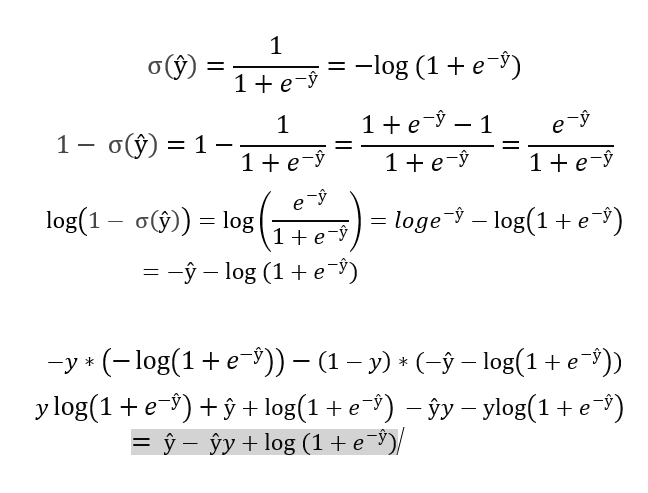


In [15]:
!cp /kaggle/input/datasets/fiktus/taskone/zd1.PNG /kaggle/working/task1.PNG

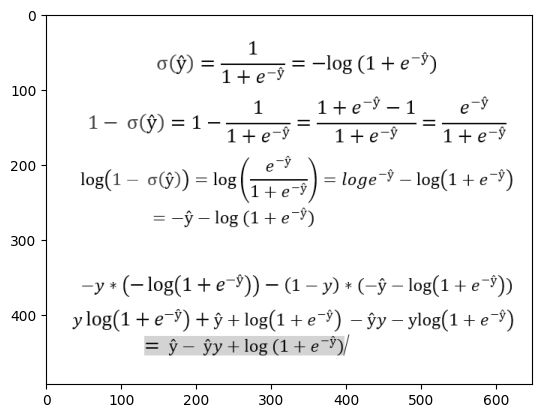

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('/kaggle/working/task1.PNG')
plt.imshow(img)

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`
  

In [17]:
import torch.nn.functional as F
import torch.nn as nn
import torch

In [18]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [19]:
def bce_loss(y_pred, y_real):
  return -torch.sum(y_real* torch.log(torch.sigmoid(y_pred)) + (1-y_real)*torch.log(1-torch.sigmoid(y_pred)))

def bce_true(y_pred, y_real):
  return torch.sum(y_pred - y_pred*y_real + torch.log(1 + torch.exp(-y_pred)))

Проверим корректность работы на простом примере

In [20]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss             = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный                = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch  = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss             = 5.180444717407227
BCE loss честно посчитанный                = 5.180445194244385
BCE loss from torch bce_torch              = 5.180445194244385
BCE loss from torch with logits bce_torch  = 5.180445194244385


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [21]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [22]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 16.25192642211914
BCE loss честно посчитанный               = 16.25192642211914
BCE loss from torch bce_torch             = 16.25192642211914
BCE loss from torch with logits bce_torch = 16.25192642211914


In [23]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [24]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /kaggle/working/for_asserts/labels.pt
100%|██████████████████████████████████████| 1.18k/1.18k [00:00<00:00, 5.80MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /kaggle/working/for_asserts/logits.pt
100%|██████████████████████████████████████| 1.18k/1.18k [00:00<00:00, 5.21MB/s]
Download completed


In [25]:
path_to_dummy_samples = '/kaggle/working/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

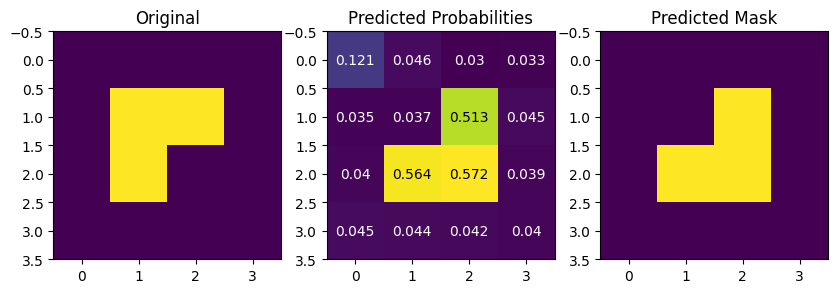

In [26]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [27]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

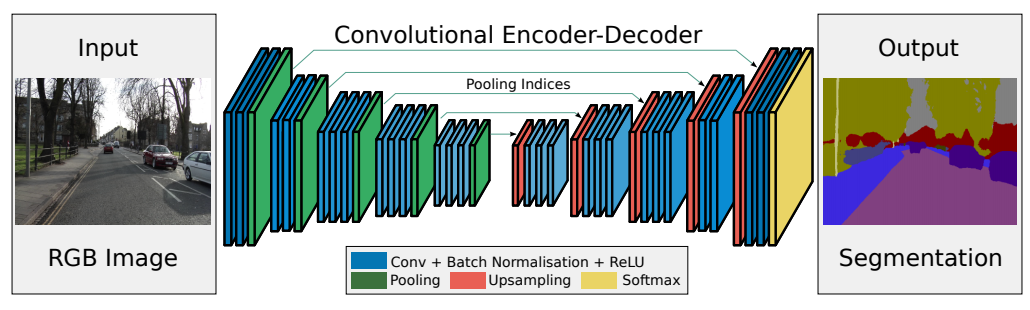

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [29]:
model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 225MB/s] 


In [30]:
model_vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [31]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


In [32]:

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1, a=True):
        super(DecoderBlock, self).__init__()
        self.layers = nn.ModuleList()
        if a:
            # первый блок
            self.layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))
            for i in range(depth-1):
                self.layers.append(nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding))
                self.layers.append(nn.BatchNorm2d(out_channels))
                self.layers.append(nn.ReLU(inplace=True))
        else:
            # только свёртки без нормализации и активации
            self.layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding))
            for i in range(depth-1):
                self.layers.append(nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding))
        self.maxunpooling = nn.MaxUnpool2d(kernel_size=2, stride=2)
    def forward(self,x, indices):
        x = self.maxunpooling(x, indices)
        for layer in self.layers:
            x = layer(x)
        return x


Соединим блоки энкодера и декодера в модель SegNet:

In [33]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels = 1, num_features = 64) -> None:
        super(SegNet, self).__init__()

        # Encoder
        self.encoder0 = EncoderBlock(in_channels, num_features, depth=2)
        self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=2)
        self.encoder2 = EncoderBlock(num_features * 2, num_features * 2 * 2, depth=3)
        self.encoder3 = EncoderBlock(num_features * 2 * 2, num_features * 2 * 2 * 2, depth=3)

        # Encoder bottleneck - количество каналов на входе и на выходе одинаково
        self.encoder4 = EncoderBlock(num_features * 2 * 2* 2, num_features * 2 * 2 * 2, depth=3)

        # Decoder bottleneck
        self.decoder4 = DecoderBlock(num_features * 2 * 2* 2, num_features * 2 * 2 * 2, depth=3)
        self.decoder3 = DecoderBlock(num_features * 2 * 2* 2, num_features * 2 * 2, depth=3)
        self.decoder2 = DecoderBlock(num_features * 2 * 2, num_features * 2, depth=3)
        self.decoder1 = DecoderBlock(num_features * 2 , num_features, depth=2)
        self.decoder0 = DecoderBlock(num_features, out_channels, depth=2, a = False)

        
        # Decoder
        # TODO

    def forward(self, x):
        # encoder
        x, indices0 = self.encoder0(x)
        x, indices1 =  self.encoder1(x)
        x, indices2 = self.encoder2(x)
        x, indices3 =  self.encoder3(x)
        x, indices4 = self.encoder4(x)
        
        # TODO
        output = self.decoder4(x, indices4)
        output = self.decoder3(output, indices3)
        output = self.decoder2(output, indices2)
        output = self.decoder1(output, indices1)
        output = self.decoder0(output, indices0)
        return output  # no activation

## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [34]:
from tqdm.notebook import tqdm

In [35]:
def fit_one_epoch(model, loss_func, optimizer, dataloader): #iou_score, train_dataloader
    model.train()
    metr = []
    for x_batch, y_batch in tqdm(dataloader):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outp = model.forward(x_batch)
        loss = loss_func(outp, y_batch)
        loss.backward()
        optimizer.step()

        pred = (torch.sigmoid(outp) > 0.5)

        metr.append(iou_score(pred, y_batch))
        
    return [sum(metr)/len(metr), loss]
        
        

In [36]:

def eval_one_epoch(model, dataloader):
    metr = []
    model.eval()
    for x_batch, y_batch in tqdm(dataloader):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        with torch.no_grad():
            logits = model(x_batch)
            preds = (torch.sigmoid(logits)>0.5)
        metr.append(iou_score(preds, y_batch))
    
    return sum(metr)/len(metr)
    


In [37]:
import copy
def train_func(model, num_epochs, train_dataloader , test_dataloader, optimizer, loss_func):
    
    iou_s = {"train": [], "valid": []}
    w_ep = copy.deepcopy(model.state_dict())
    temp_iou = 0
    for epoch in tqdm(range(num_epochs)):
        print(f"\nEpoch: {epoch+1}")
        
        iou_train_one_epoch = fit_one_epoch(model = model, dataloader = train_dataloader, optimizer = optimizer, loss_func = loss_func)
        
          
        print(f"iou_train: {iou_train_one_epoch[0]}\n")
        print(f"loss: {iou_train_one_epoch[1]}\n")
        iou_test_one_epoch = eval_one_epoch(model = model, dataloader = test_dataloader )
        print(f"iou_test: {iou_test_one_epoch.item()}\n")
          
        if temp_iou < iou_test_one_epoch:
            w_ep, temp_iou = copy.deepcopy(model.state_dict()), iou_test_one_epoch
            print('Сохранено!')
          
        iou_s['train'].append(iou_train_one_epoch[0])
        iou_s['valid'].append(iou_test_one_epoch)
    model.load_state_dict(w_ep)
    del w_ep
    return iou_s


# Аномалии обучения скорее всего вызваны маленьким датасетом

In [38]:
savemodel = SegNet().to(device)
loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(savemodel.parameters(), lr = 2e-4 )


max_epochs = 20
iou1 = train_func(model = savemodel, num_epochs = max_epochs, train_dataloader = train_dataloader, test_dataloader = test_dataloader
                      , optimizer = optimizer, loss_func = loss)


  0%|          | 0/20 [00:00<?, ?it/s]


Epoch: 1


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.3007073700428009

loss: 0.7335907816886902



  0%|          | 0/2 [00:00<?, ?it/s]

...

iou_test: 0.5448487401008606

Сохранено!

Epoch: 20


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.6012210249900818

loss: 0.5205338001251221



  0%|          | 0/2 [00:00<?, ?it/s]

iou_test: 0.596158504486084

Сохранено!


Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [39]:

def test(model,dataloader):
    metr = []#test_dataloader
    model.eval()
    for x_batch, y_batch in tqdm(dataloader):
        
        
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        with torch.no_grad():
            logits = model(x_batch)
            preds = (torch.sigmoid(logits)>0.5)
        metr.append(iou_score(preds, y_batch))
    
    return sum(metr)/len(metr)

In [40]:
f = test(savemodel, test_dataloader)

  0%|          | 0/2 [00:00<?, ?it/s]

In [41]:
f

tensor(0.5962, device='cuda:0')

# Задания: Мир других лоссов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [42]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    '''
    Это именно метрика, не лосс.
    '''
    w = torch.sigmoid(logits) > threshold
    tp = torch.sum(w*labels)
    fn = torch.sum(labels) - torch.sum(w*labels)
    fp =  torch.sum(w) - tp
    e = 1e-8
    score = (2*tp + e)/ (2*tp + fn + fp + e)
    return score

Проверим на корректность функцию dice_score:

In [43]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.8 MB/s eta 0:00:00


In [44]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='micro').to(device)
dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))
#в д.з выдаёт 0.6667, как и написанная выше кастомная

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


tensor(0.3158, device='cuda:0')

In [45]:
'''
если вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():

from torchmetrics.classification import Dice

dice = Dice(average='micro').to(device)

'''
print(dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int)))
print(dice_score(dummpy_sample['logits'], dummpy_sample['labels']))

tensor(0.3158, device='cuda:0')
tensor(0.6667, device='cuda:0')


In [46]:
assert dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int)) == dice_score(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [47]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):

    w = torch.sigmoid(logits) 
    tp = torch.sum(w*labels)
    fn = torch.sum(labels) - torch.sum(w*labels)
    fp =  torch.sum(w) - tp
    e = 1e-8
    score = (2*tp + e)/ (2*tp + fn + fp + e)
    loss = 1 - score
    return loss

Проверка на корректность:

In [48]:
# проверьте, что у вас установлена библиотека
!pip install segmentation-models-pytorch

In [49]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [50]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [51]:


def focal_loss(y_pred, y_true, eps=1e-8, gamma=2):
    
    pt = torch.sigmoid(y_pred)*y_true + (1- torch.sigmoid(y_pred))*(1-y_true)
    lbce = -torch.log(pt+eps)
    fc_w = (1-pt)**gamma
    loss = (fc_w * lbce).mean()
    

    return loss# я поменял на mean чтобы не были такие огромные потери (но на iou не влияло, по сути просто для красоты)

Проверка корректности функции:

In [52]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], gamma=2, reduction='mean')

tensor(0.0653, device='cuda:0')

In [53]:
assert np.isclose(sigmoid_focal_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu(), alpha=-1, gamma=2, reduction='mean'), focal_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu(), gamma=2.0))

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями. ВАЖНО: за имплементацию одного лосса выдается только один балл. Чтобы получить все 5 баллов, будет необходимо имплементировать все 5 лоссов.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

In [54]:
#идея в том, чтобы сосредоточить внимания сети на определённых участках лица и этот луз в этом помогает, 

def physiological_loss(logits, targets, lambda_sp=0.01, lambda_sc=0.01):
    probs = torch.sigmoid(logits)
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='mean')
    l_sp = torch.mean(torch.abs(probs - 0.5))
    diff_h = probs[:, :, 1:, :] - probs[:, :, :-1, :]
    diff_v = probs[:, :, :, 1:] - probs[:, :, :, :-1]
    l_sc = torch.mean(torch.abs(diff_h)) + torch.mean(torch.abs(diff_v))
    return bce + lambda_sp * l_sp + lambda_sc * l_sc


In [55]:
from scipy.ndimage import distance_transform_edt
#По истинной маске вычисляется карта расстояний до ближайшей границы (distance transform) – каждый пиксель получает вес, пропорциональный удалённости от контура.
#эти веса используются в bce
#по идее звучит очень хорощо, но результат не очень
def boundary_loss(logits, y_true):
    m = y_true.cpu().squeeze(1).numpy()                # (B, H, W)
    dist = np.stack([distance_transform_edt(d) + distance_transform_edt(1 - d)
                     for d in m])
    w = torch.as_tensor(dist, dtype=torch.float32, device=y_true.device).unsqueeze(1)
    w = w / (w.max() + 1e-8)

    return F.binary_cross_entropy_with_logits(logits, y_true, weight=w, reduction='mean')

In [56]:
# гибкий diceloss, управление коэффициентами fn, fp при помощи коэффициентов,

def tversky_loss(logits, y_true, alpha=0.7, beta=0.3, smooth=1.0):
    y_pred = torch.sigmoid(logits)               
    y_pred = y_pred.view(-1)
    y_true = y_true.view(-1)
    tp = (y_pred * y_true).sum()
    fp = (y_pred * (1 - y_true)).sum()
    fn = ((1 - y_pred) * y_true).sum()
    tversky = (tp + smooth) / (tp + alpha * fn + beta * fp + smooth)
    return 1 - tversky

In [57]:
# данный луз применяется для выявления структурных паттернов, а не просто попиксельно при помощи сравнения дисперсии, яркости, 
#ковариации( согласованность изменений помошает выявлять паттерны)
def ssim_loss(logits, y_true, win=11, C1=0.01**2, C2=0.03**2):
    y_pred = torch.sigmoid(logits)
    g = torch.exp(-((torch.arange(win, dtype=torch.float32) - win//2)**2) / (2*1.5**2))
    g /= g.sum()
    w = (g[None,None,:,None] * g[None,None,None,:]).to(y_pred.device)
    mu1 = F.conv2d(y_pred, w, padding=win//2)
    mu2 = F.conv2d(y_true, w, padding=win//2)
    mu12, mu1_sq, mu2_sq = mu1*mu2, mu1**2, mu2**2
    s1 = F.conv2d(y_pred**2, w, padding=win//2) - mu1_sq
    s2 = F.conv2d(y_true**2, w, padding=win//2) - mu2_sq
    s12 = F.conv2d(y_pred*y_true, w, padding=win//2) - mu12
    ssim_map = ((2*mu12 + C1)*(2*s12 + C2)) / ((mu1_sq+mu2_sq+C1)*(s1+s2+C2))
    return 1 - ssim_map.mean()

In [58]:
#вычисляется градиент изображения, показывающий края объектов,  считается средняя абсолютная разница между картами краёв  y_pred и y_true.
#по сути помогает сохранить непрерывность объекта, его контуры
def topology_loss(logits, y_true):
    y_pred = torch.sigmoid(logits)
    def grad(x):
        kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32, device=x.device).view(1,1,3,3)
        ky = kx.transpose(2,3)
        return torch.sqrt(F.conv2d(x, kx, padding=1)**2 + F.conv2d(x, ky, padding=1)**2 + 1e-8)
    return (grad(y_pred) - grad(y_true)).abs().mean()

## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.

Лучший результат выдаёт tversky_loss, модель сходится лучше всего также с этой функцией потерь, которая по сути является diceloss ( который выдал тоже хороший результат ( 0.69 )), но с гибкими настройками. у нас увеличенный коэффициент a, это увеличивает штраф за пропуск объекта (fn), что хорошо подходит под задачу выявления  образований по типу родинок.

In [59]:
model = SegNet().to(device)
loss = DiceLoss(mode='binary')# это импортированная функция потерь, значения всё-равно странные, я проверил функции обучения несколько раз. Но в итоге обучение идёт
optimizer = torch.optim.AdamW(model.parameters(), lr = 2e-4 )


max_epochs = 15
iou2 = train_func(model = model, num_epochs = max_epochs, train_dataloader = train_dataloader, test_dataloader = test_dataloader
                      , optimizer = optimizer, loss_func = loss)
del model

  0%|          | 0/15 [00:00<?, ?it/s]


Epoch: 1


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.12962113320827484

loss: 0.6450744867324829



  0%|          | 0/2 [00:00<?, ?it/s]

...

iou_test: 0.6547677516937256


Epoch: 15


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.7143300771713257

loss: 0.44851696491241455



  0%|          | 0/2 [00:00<?, ?it/s]

iou_test: 0.5800371170043945



In [60]:
model = SegNet().to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr = 3e-4 )
loss = focal_loss

max_epochs = 15
iou3 = train_func(model = model, num_epochs = max_epochs, train_dataloader = train_dataloader, test_dataloader = test_dataloader
                      , optimizer = optimizer, loss_func = loss)


  0%|          | 0/15 [00:00<?, ?it/s]


Epoch: 1


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.20709621906280518

loss: 0.17287664115428925



  0%|          | 0/2 [00:00<?, ?it/s]

...

iou_test: 0.26198577880859375

Сохранено!

Epoch: 15


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.3083765506744385

loss: 0.1428433060646057



  0%|          | 0/2 [00:00<?, ?it/s]

iou_test: 0.2987220883369446

Сохранено!


In [61]:
model = SegNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr = 3e-4)
loss = physiological_loss

max_epochs = 15
iouphis = train_func(model = model, num_epochs = max_epochs, train_dataloader = train_dataloader, test_dataloader = test_dataloader
                      , optimizer = optimizer, loss_func = loss)
del model

  0%|          | 0/15 [00:00<?, ?it/s]


Epoch: 1


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.3053409457206726

loss: 0.7262992858886719



  0%|          | 0/2 [00:00<?, ?it/s]

...

iou_test: 0.7063764929771423

Сохранено!

Epoch: 15


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.6946413516998291

loss: 0.35087043046951294



  0%|          | 0/2 [00:00<?, ?it/s]

iou_test: 0.6382808685302734



In [62]:
model = SegNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr = 3e-4)
loss = boundary_loss

max_epochs = 15
iou4 = train_func(model = model, num_epochs = max_epochs, train_dataloader = train_dataloader, test_dataloader = test_dataloader
                      , optimizer = optimizer, loss_func = loss)
del model

  0%|          | 0/15 [00:00<?, ?it/s]


Epoch: 1


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.004424853250384331

loss: 0.13957926630973816



  0%|          | 0/2 [00:00<?, ?it/s]

...

iou_test: 0.41731759905815125


Epoch: 15


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.5649331212043762

loss: 0.09198592603206635



  0%|          | 0/2 [00:00<?, ?it/s]

iou_test: 0.4904816746711731

Сохранено!


In [63]:
model = SegNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr = 2e-4, weight_decay=2e-4 )
loss = tversky_loss

max_epochs = 15
iou5 = train_func(model = model, num_epochs = max_epochs, train_dataloader = train_dataloader, test_dataloader = test_dataloader
                      , optimizer = optimizer, loss_func = loss)
del model

  0%|          | 0/15 [00:00<?, ?it/s]


Epoch: 1


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.09287236630916595

loss: 0.5761653184890747



  0%|          | 0/2 [00:00<?, ?it/s]

...

iou_test: 0.7104312181472778

Сохранено!

Epoch: 15


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.7636948823928833

loss: 0.368918776512146



  0%|          | 0/2 [00:00<?, ?it/s]

iou_test: 0.6945270895957947



In [64]:
model = SegNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr = 2e-4, weight_decay=2e-4 )
loss = ssim_loss

max_epochs = 15
iou6 = train_func(model = model, num_epochs = max_epochs, train_dataloader = train_dataloader, test_dataloader = test_dataloader
                      , optimizer = optimizer, loss_func = loss)


  0%|          | 0/15 [00:00<?, ?it/s]


Epoch: 1


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.30574676394462585

loss: 0.807185709476471



  0%|          | 0/2 [00:00<?, ?it/s]

...

iou_test: 0.32742631435394287

Сохранено!

Epoch: 15


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.32362276315689087

loss: 0.7596024870872498



  0%|          | 0/2 [00:00<?, ?it/s]

iou_test: 0.3318486213684082

Сохранено!


# Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

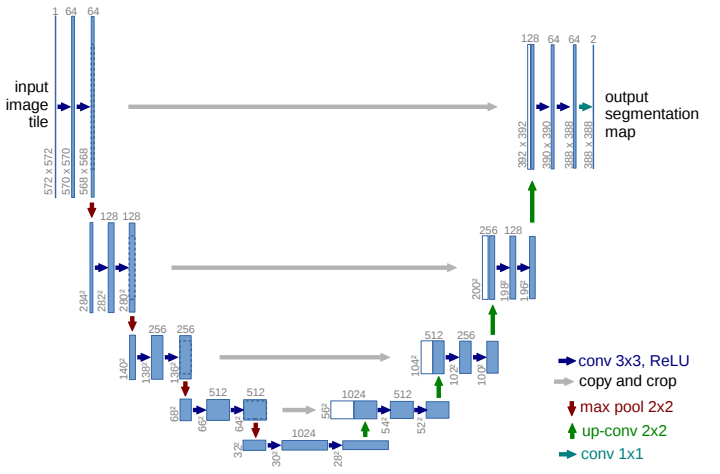

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

## Обучите UNet

In [65]:
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        before_pool = x                     # сохраняем до пулинга (для skip)
        x, indices = self.maxpooling(x)     # после пулинга (для следующего уровня)
        return before_pool, x, indices

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1, a=True):
        super(DecoderBlock, self).__init__()
        self.layers = nn.ModuleList()
        if a:
            # первый блок
            self.layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))
            for i in range(depth-1):
                self.layers.append(nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding))
                self.layers.append(nn.BatchNorm2d(out_channels))
                self.layers.append(nn.ReLU(inplace=True))
        else:
            # только свёртки без нормализации и активации
            self.layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding))
            for i in range(depth-1):
                self.layers.append(nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding))
        self.maxunpooling = nn.MaxUnpool2d(kernel_size=2, stride=2)
    # forward без изменений
    def forward(self,x, indices, skip = None):
        x = self.maxunpooling(x, indices)
        if skip is not None:
            x = torch.cat([x, skip], dim = 1)
        for layer in self.layers:
            x = layer(x)
        return x

In [66]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels = 1, num_features = 64):
        super(UNet, self).__init__()
        self.encoder0 = EncoderBlock(in_channels, num_features, depth=2)
        self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=2)
        self.encoder2 = EncoderBlock(num_features * 2, num_features * 2 * 2, depth=2)
        self.encoder3 = EncoderBlock(num_features * 2 * 2, num_features * 2 * 2 * 2, depth=2) # 32

        # Encoder bottleneck - количество каналов на входе и на выходе одинаково
        self.encoder4 = EncoderBlock(num_features * 2 * 2* 2, num_features * 2 * 2 * 2, depth=1)
        # Decoder bottleneck
        self.decoder4 = DecoderBlock(num_features * 2 * 2* 2, num_features * 2 * 2 * 2, depth=1)
        
        self.decoder3 = DecoderBlock(num_features * 2 * 2* 2 + num_features * 2 * 2* 2, num_features * 2 * 2, depth=2)#32
        self.decoder2 = DecoderBlock(num_features * 2 * 2 + num_features * 2 * 2, num_features * 2, depth=2)
        self.decoder1 = DecoderBlock(num_features * 2 + num_features * 2 , num_features, depth=2)
        self.decoder0 = DecoderBlock(num_features + num_features, out_channels, depth=2, a = False)
        self.sigmoid = nn.Sigmoid()
            

    def forward(self, x):
        #  TODO
        
        skip0, x, indices0 = self.encoder0(x)
       
        skip1, x, indices1 =  self.encoder1(x)
        
        skip2, x, indices2 = self.encoder2(x)
        
        skip3, x, indices3 =  self.encoder3(x)
        

        
        skip4, x, indices4 = self.encoder4(x)
        output = self.decoder4(x, indices4)

        
        # Декодер с skip-соединениями
        output = self.decoder3(output, indices3, skip=skip3)  # unpool с ind3 -> H/8, concat skip3 (H/8) -> 1024, свёртки -> 256
        output = self.decoder2(output, indices2, skip=skip2)  # unpool с ind2 -> H/4, concat skip2 (H/4) -> 512, свёртки -> 128
        output = self.decoder1(output, indices1, skip=skip1)  # unpool с ind1 -> H/2, concat skip1 (H/2) -> 256, свёртки -> 64
        output = self.decoder0(output, indices0, skip=skip0)  # unpool с ind0 -> H, concat skip0 (H) -> 128, свёртки -> 1
        #output = self.sigmoid(output)
        return output
        

        

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы. Ответ ниже



In [67]:
unet_model = UNet().to(device) 

optimizer = torch.optim.Adam(unet_model.parameters(), lr = 2e-4)


max_epochs = 15
iou7 = train_func(model = unet_model, num_epochs = max_epochs, train_dataloader = train_dataloader, test_dataloader = test_dataloader
                      , optimizer = optimizer, loss_func = focal_loss)


  0%|          | 0/15 [00:00<?, ?it/s]


Epoch: 1


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.4095430374145508

loss: 0.13800862431526184



  0%|          | 0/2 [00:00<?, ?it/s]

...

iou_test: 0.7360996007919312


Epoch: 15


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.8293826580047607

loss: 0.055018384009599686



  0%|          | 0/2 [00:00<?, ?it/s]

iou_test: 0.708761990070343



In [68]:
unet_model1 = UNet().to(device)
loss = DiceLoss(mode='binary')
optimizer = torch.optim.AdamW(unet_model1.parameters(), lr = 2e-4)


max_epochs = 15
iou8 = train_func(model = unet_model1, num_epochs = max_epochs, train_dataloader = train_dataloader, test_dataloader = test_dataloader
                      , optimizer = optimizer, loss_func=loss)


  0%|          | 0/15 [00:00<?, ?it/s]


Epoch: 1


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.027875909581780434

loss: 0.6407946348190308



  0%|          | 0/2 [00:00<?, ?it/s]

...

iou_test: 0.6543325185775757

Сохранено!

Epoch: 15


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.671157956123352

loss: 0.3510422706604004



  0%|          | 0/2 [00:00<?, ?it/s]

iou_test: 0.6835293769836426

Сохранено!


In [69]:
unet_model2 = UNet().to(device)
loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(unet_model2.parameters(), lr = 2.5e-4)


max_epochs = 20
iou9 = train_func(model = unet_model2, num_epochs = max_epochs, train_dataloader = train_dataloader, test_dataloader = test_dataloader
                      , optimizer = optimizer, loss_func = loss)


  0%|          | 0/20 [00:00<?, ?it/s]


Epoch: 1


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.3398968577384949

loss: 0.6753556728363037



  0%|          | 0/2 [00:00<?, ?it/s]

...

iou_test: 0.8134515285491943

Сохранено!

Epoch: 20


  0%|          | 0/4 [00:00<?, ?it/s]

iou_train: 0.8323251605033875

loss: 0.24951010942459106



  0%|          | 0/2 [00:00<?, ?it/s]

iou_test: 0.8194948434829712

Сохранено!


In [70]:
print(1,'   ', max(iou1['valid']).item())
print(2,'   ', max(iou2['valid']).item())
print(3,'   ', max(iou3['valid']).item())
print(4,'   ', max(iou4['valid']).item())
print(5,'   ', max(iou5['valid']).item())
print(6,'   ', max(iou6['valid']).item())
print(7,'   ', max(iou7['valid']).item())
print(8,'   ', max(iou8['valid']).item())
print(9,'   ', max(iou9['valid']).item())

# loss не сохранял, но выводил


1     0.596158504486084
2     0.6949430704116821
3     0.2987220883369446
4     0.4904816746711731
5     0.7104312181472778
6     0.3318486213684082
7     0.7450519800186157
8     0.6835293769836426
9     0.8194948434829712



* Какая модель дает лучшие значения по метрике? лучшие значения даёт модель Unet (7- 9) с стандартным BCE, вероятно другие функции потерь дали бы преимущество в сложной задаче с большим датасетом ( а возможно и в нашей задаче просто с большим числом эпох обучения)
  
* Какая модель обучается быстрее? unet практически сразу выдаёт результат выше 0.72 iou, в то время как segnet c bce потребовалось на это 15 эпох,  по времени unet и segnet учатся одинаково ( возможно незаметна разница из-за маленького датасета)


* Какая модель дает лучшие значения по лоссам? loss также падает у unet гораздо быстрее (у segnet к 20 эпохе loss = 0.5, у unet к 20 эпохе loss = 0.2495 ( на bce ))
  

  
* Сравните визуально результаты SegNet и UNet.  В Unet наюлюдаются гораздо более гладкие края, отсутствует шум (ниже)



# Сравнивать буду 2 модели с bceloss, 20 эпох обучения
# Видим явные отличия unet от segnet. у unet нет шума, гораздо более точная сегментация. (у segnet iou 0.596, у unet 0.819)

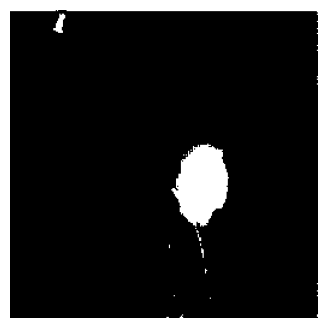

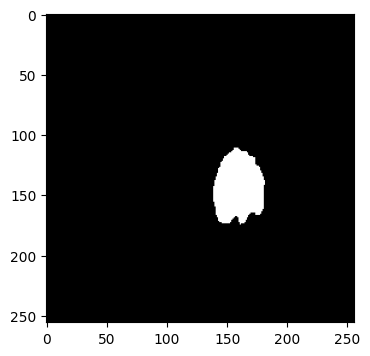

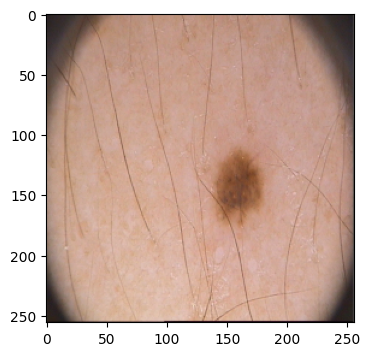

In [71]:
import torch
import matplotlib.pyplot as plt


model.eval()

with torch.no_grad():
   
    input_tensor = torch.from_numpy(X[0]).float()  # (H, W, C)        
    input_tensor = input_tensor.permute(2, 0, 1)# (C, H, W) 
    input_tensor = input_tensor.unsqueeze(0).to(device) # (1,C,H,W) 

 

    logits = unet_model2(input_tensor)                   
    probs = torch.sigmoid(logits)
    masks = (probs > 0.5).float()

mask = masks[0, 0].cpu().numpy()      


plt.imshow(mask, cmap='gray')

plt.axis('off')
plt.show()
plt.imshow(Y[0], cmap='gray')

plt.show()
plt.imshow(X[0], cmap='gray')

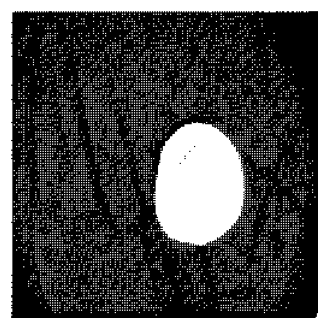

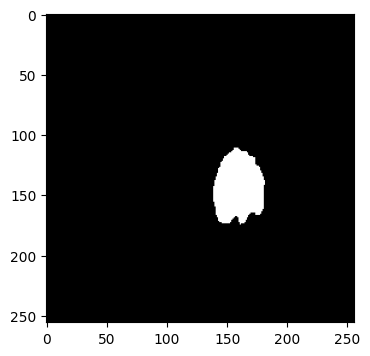

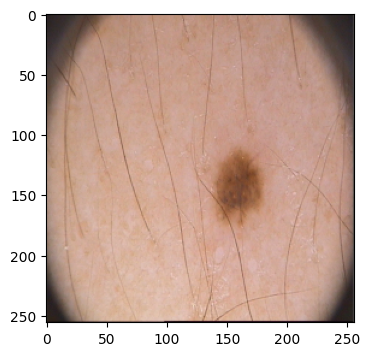

In [72]:
import torch
import matplotlib.pyplot as plt


model.eval()

with torch.no_grad():

    input_tensor = torch.from_numpy(X[0]).float()  # (H, W, C)
    input_tensor = input_tensor.permute(2, 0, 1)# (C, H, W) 
    input_tensor = input_tensor.unsqueeze(0).to(device)# (1, C, H, W) 

    logits = savemodel(input_tensor)             
    probs = torch.sigmoid(logits)
    masks = (probs > 0.5).float()

mask = masks[0, 0].cpu().numpy()       

# Визуализация
plt.imshow(mask, cmap='gray')

plt.axis('off')
plt.show()
plt.imshow(Y[0], cmap='gray')

plt.show()
plt.imshow(X[0], cmap='gray')

Ответы выше